# Heatmaps

To better understand the patterns of expression across samples, I'm going to plot heatmaps of DEGs in pairwise comparisons using the outputs from [filter_deseq_p1.v.p1.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/new_refGenome/filter_deseq_p1.v.p1.ipynb)

## 0. load libraries

In [13]:
library(tidyverse)
library(pheatmap)

## 1. load csvs

### a. all genes

In [16]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq',
    pattern = '\\.csv$',
    full.names = TRUE
    )

# Read each CSV
p1.list <- lapply(files, function(f) {
    df <- read.csv(f)
})

# Name each list element
names(p1.list) <- tools::file_path_sans_ext(basename(files))

# Remove p1. prefix
names(p1.list) <- sub("p1.", "", names(p1.list))

# remove vst file
p1.list$vst <- NULL

names(p1.list)

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
[6] "warm_v_cont"

In [17]:
head(p1.list$both_v_cont)

,X,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7662,0.0006761802,0.02228363,7.787130e-01,0.996744247
2,LOC144621269,6797.3814,0.0043087230,0.10996986,5.813767e-01,0.992069372
3,LOC111120925,191.4430,-4.8964652929,1.40924743,8.354541e-06,0.003583072
4,LOC144621283,932.0540,0.0011782772,0.02371156,6.197830e-01,0.992315930
5,LOC144621276,12350.8892,0.0012266111,0.02480930,5.976185e-01,0.992069372
6,LOC111115920,213.3386,0.0676324761,0.25037815,6.160028e-03,0.234887066


### b. DEGs

In [27]:
p1.deg <- lapply(p1.list, function(f) { 
    f %>% filter(abs(log2FoldChange) >= 1 & padj <= 0.05) %>%
    pull(X)
})

head(p1.deg$both_v_cont)

[1] "LOC111120925" "LOC111103173" "LOC111105159" "LOC111132252" "LOC111137262"
[6] "LOC111105069"

### c. vst
want a numeric matrix for `pheatmap`, with rows = genes and columns = samples

In [20]:
vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1_vst.csv') %>%
column_to_rownames('X')

dim(vst)
head(vst)

[1] 25196    23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,11.217975,11.934767,11.224763,11.385998,11.491494,11.330413,11.619094,11.599610,10.935631,11.347427,⋯,11.695721,11.157977,11.658281,11.998989,11.369555,11.484610,11.158177,11.698655,11.463655,11.597431
LOC144621269,9.238570,14.233747,13.248661,6.734822,7.542979,13.067731,11.252050,11.655097,11.695209,11.363168,⋯,13.172456,11.238048,8.354464,15.534626,13.113269,11.584691,11.875265,13.441989,6.077703,12.341027
LOC111120925,6.162650,6.596958,6.709412,6.097391,6.365111,6.642652,8.868688,8.893482,8.281309,6.230817,⋯,8.933040,6.529973,8.449891,8.330386,6.304683,8.790027,6.259740,6.294474,5.806396,6.516750
LOC144621283,9.891478,10.157309,10.265604,9.957131,10.370479,10.049745,9.730975,10.158138,10.091135,10.054934,⋯,10.091122,9.802983,9.406153,9.831201,9.297184,10.572628,10.579026,9.655386,10.115723,10.146704
LOC144621276,13.540965,13.766144,14.145528,13.224735,13.084951,13.044656,13.810034,13.596797,13.309595,13.414035,⋯,13.929735,13.686105,12.877924,13.996777,12.961637,13.892552,14.181140,13.333327,13.928741,13.550413
LOC111115920,8.717293,8.463000,8.350118,8.954966,9.308119,8.469442,7.913170,8.149178,8.357417,8.172624,⋯,7.567075,8.159515,8.690883,8.016850,7.795664,8.011123,8.435333,8.088760,8.136625,7.770861


### c. meta data

In [23]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
# select phase 1 samples
filter(is.na(Phase2_treatment))

dim(meta)
head(meta)

[1] 24  9

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
2,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
3,B3_Nu_O24,both,warm,hypoxic,3,NA,NA,NA,NA
4,B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
5,B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
6,B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA


## 2. plot heatmap
using `pheatmap`

In [25]:
annotation <- meta %>%
  select(Sample, Phase1_treatment) %>%
  column_to_rownames("Sample")

annotation <- annotation[colnames(vst), , drop = FALSE]

annotation_colors <- list(
  Phase1_treatment = c(
    control = "burlywood3",
    warm = "palevioletred",
      hypoxic = 'steelblue3',
      both = 'plum3'
  )
)

head(annotation)
head(annotation_colors)

,Phase1_treatment
,<chr>
B1_Nu_O03,both
B2_Nu_O12,both
B4_Nu_O32,both
B5_Nu_O36,both
B6_Nu_O47,both
C1_Nu_W01,control


$Phase1_treatment
        control            warm         hypoxic            both 
   "burlywood3" "palevioletred"    "steelblue3"         "plum3"

#### W vs. C

In [40]:
# pull sample names
wc_sample <- meta %>% filter(Phase1_treatment %in% c('warm', 'control')) %>% pull(Sample)

# pull rows and cols from vst matrix
wc.matrix <- vst[rownames(vst) %in% p1.deg$warm_v_cont, colnames(vst) %in% wc_sample]

length(p1.deg$warm_v_cont)
dim(wc.matrix)

[1] 61

[1] 61 12

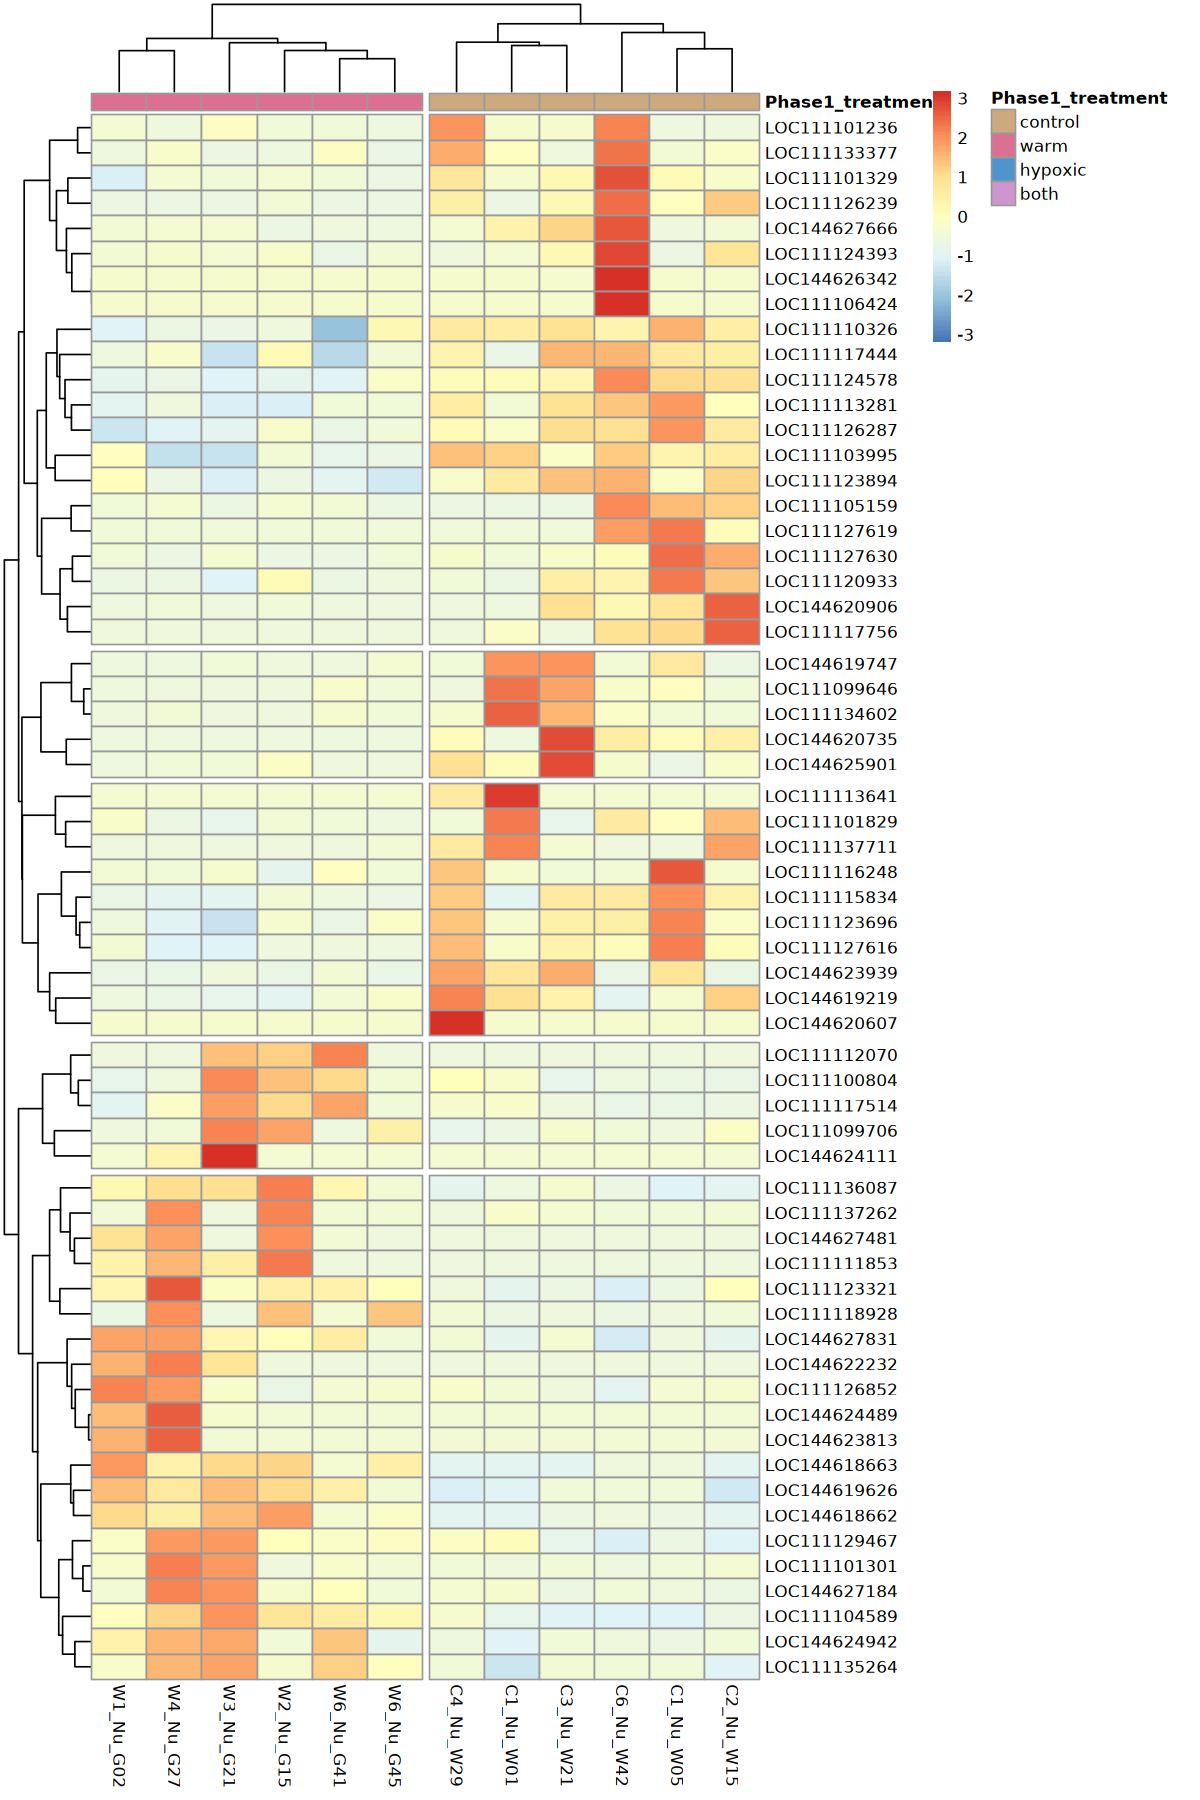

In [43]:
options(repr.plot.height = 15, repr.plot.width = 10)

pheatmap(wc.matrix,
         # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 5, 
         cutree_cols = 2,
        scale = 'row' # standardizes each gene separately across samples
        ) 

#### H vs. C

In [45]:
# pull sample names
hc_sample <- meta %>% filter(Phase1_treatment %in% c('warm', 'control')) %>% pull(Sample)

# pull rows and cols from vst matrix
hc.matrix <- vst[rownames(vst) %in% p1.deg$hyp_v_cont, colnames(vst) %in% hc_sample]

# check dimensions
length(p1.deg$hyp_v_cont)
dim(hc.matrix)

[1] 30

[1] 30 12

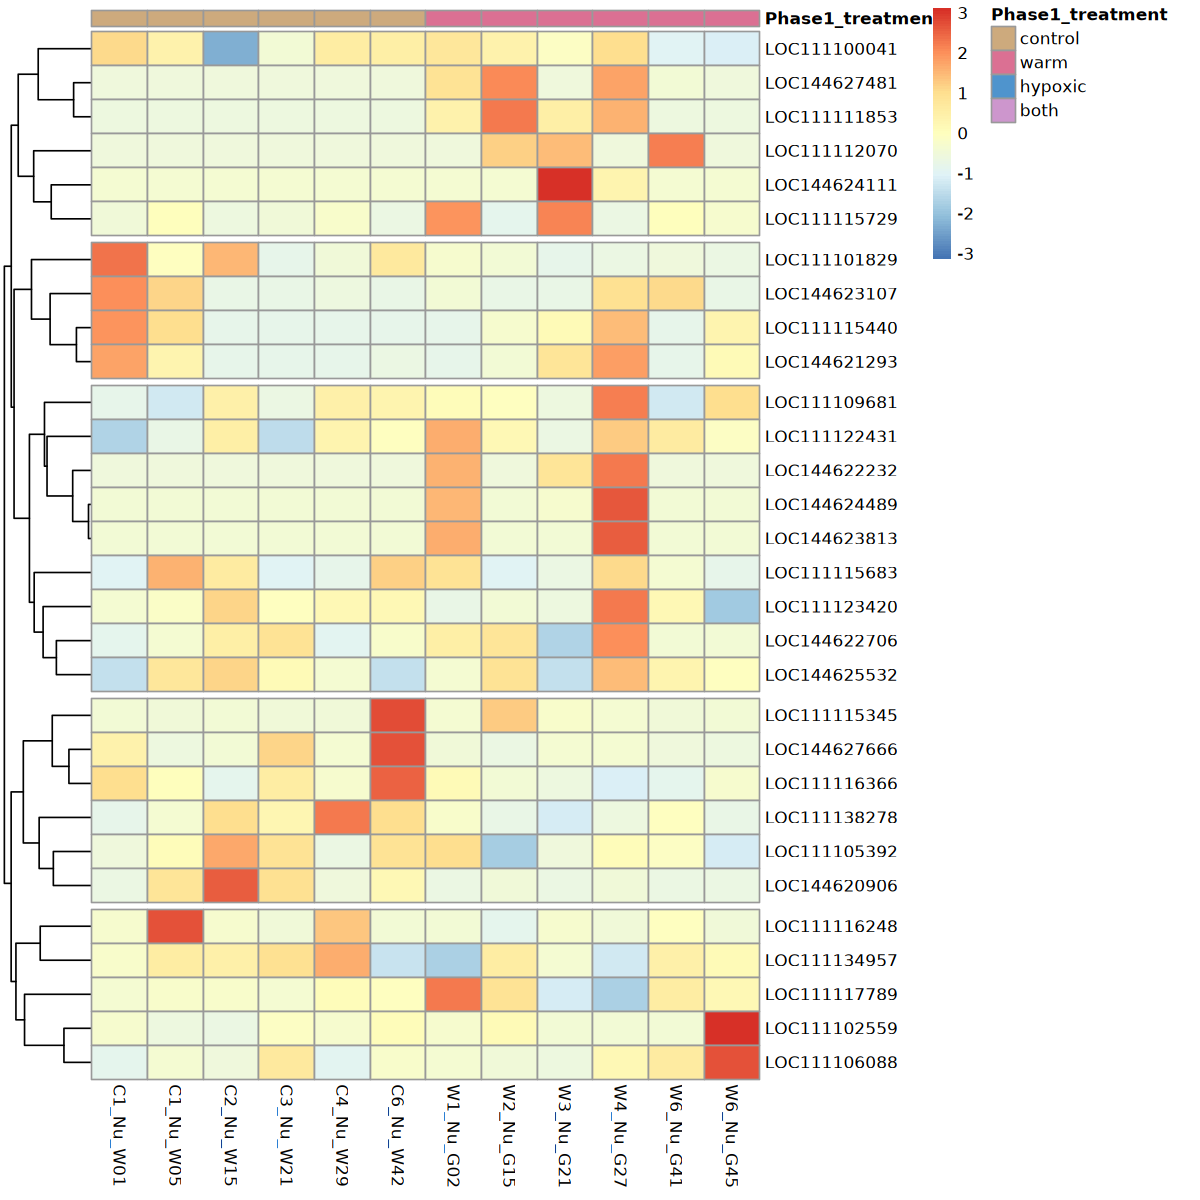

In [50]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(hc.matrix,
        cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 5, 
         cutree_cols = 2,
        scale = 'row' # standardizes each gene separately across samples
        ) 

#### B vs. C

In [51]:
# pull sample names
bc_sample <- meta %>% filter(Phase1_treatment %in% c('both', 'control')) %>% pull(Sample)

# pull rows and cols from vst matrix
bc.matrix <- vst[rownames(vst) %in% p1.deg$both_v_cont, colnames(vst) %in% bc_sample]

length(p1.deg$both_v_cont)
dim(bc.matrix)

[1] 216

[1] 216  11

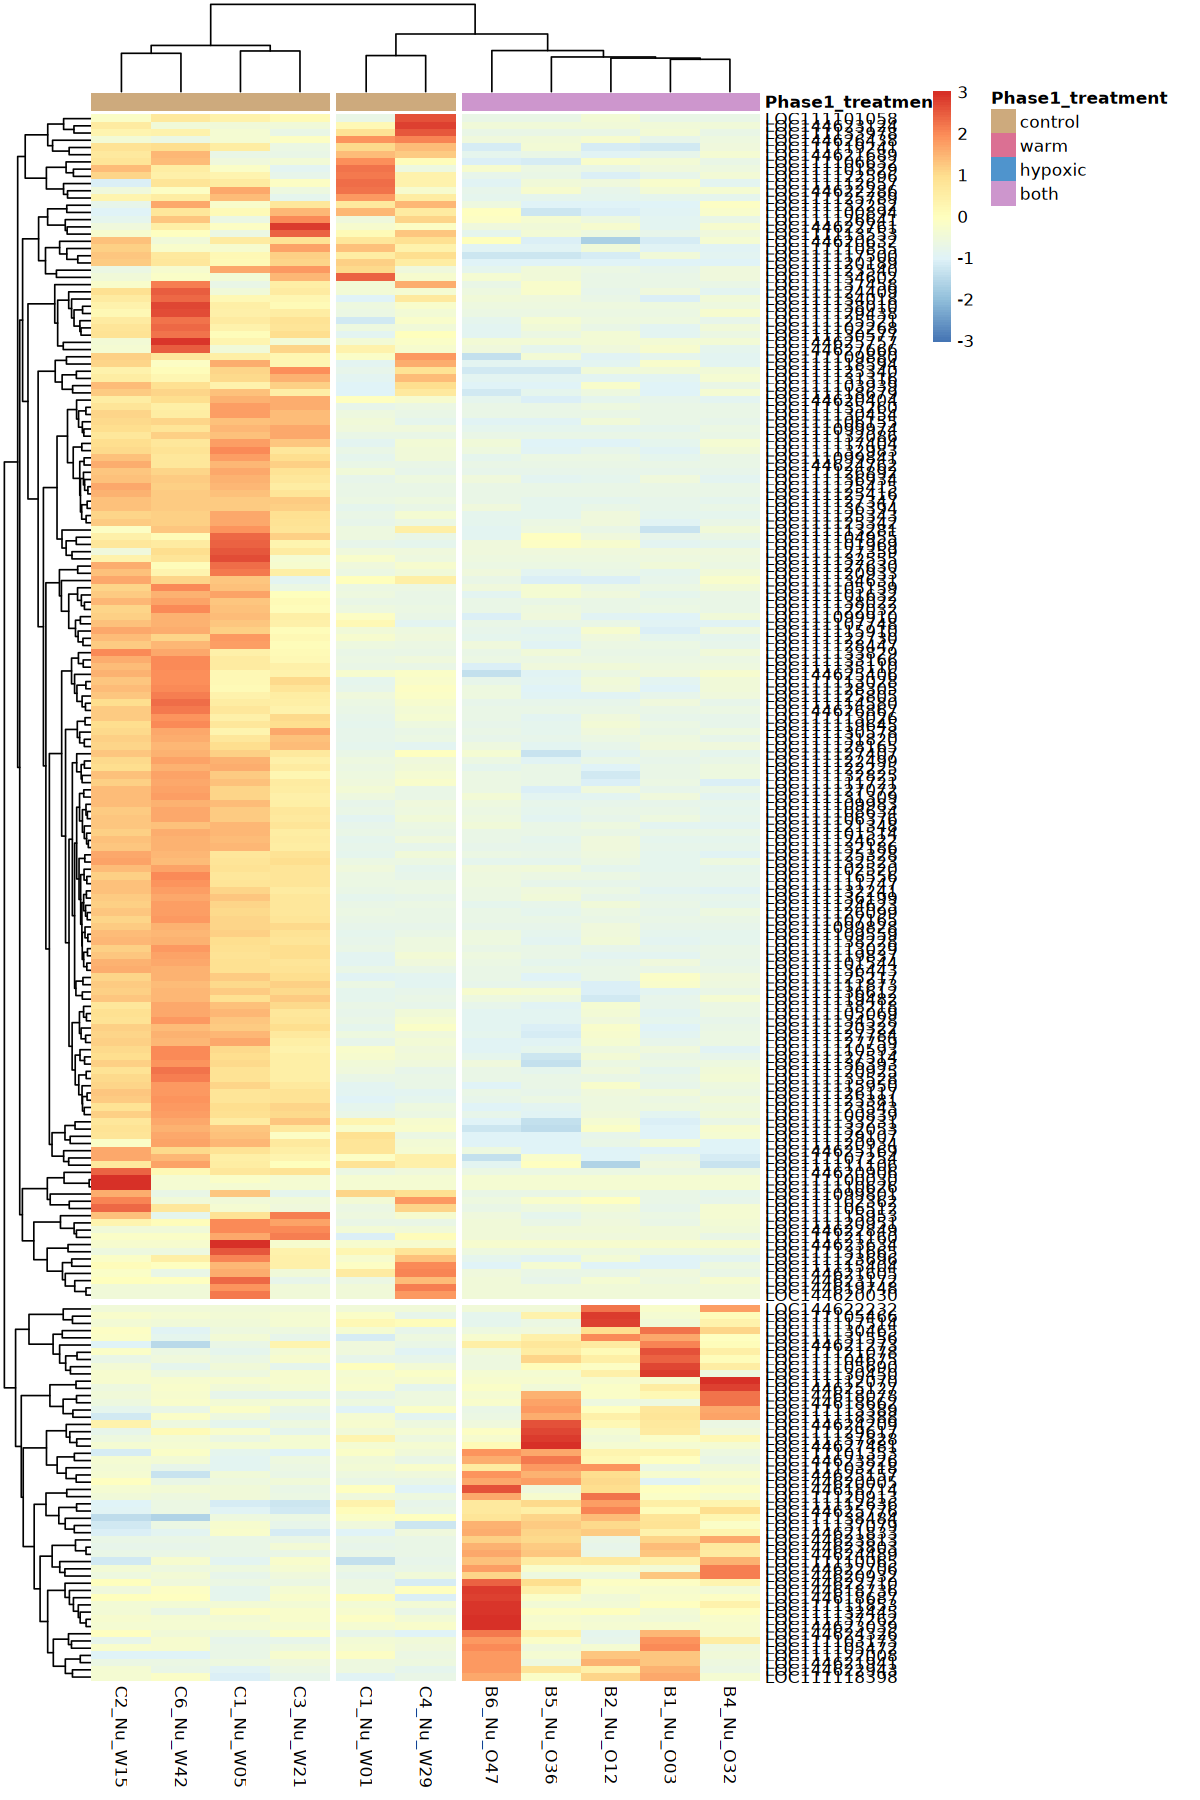

In [63]:
options(repr.plot.height = 15, repr.plot.width = 10)

pheatmap(bc.matrix,
         # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 3,
        scale = 'row' # standardizes each gene separately across samples
        ) 

#### W vs. H

In [56]:
# pull sample names
wh_sample <- meta %>% filter(Phase1_treatment %in% c('warm', 'hypoxic')) %>% pull(Sample)

# pull rows and cols from vst matrix
wh.matrix <- vst[rownames(vst) %in% p1.deg$hyp_v_warm, colnames(vst) %in% wh_sample]

length(p1.deg$hyp_v_warm)
dim(wh.matrix)

[1] 50

[1] 50 12

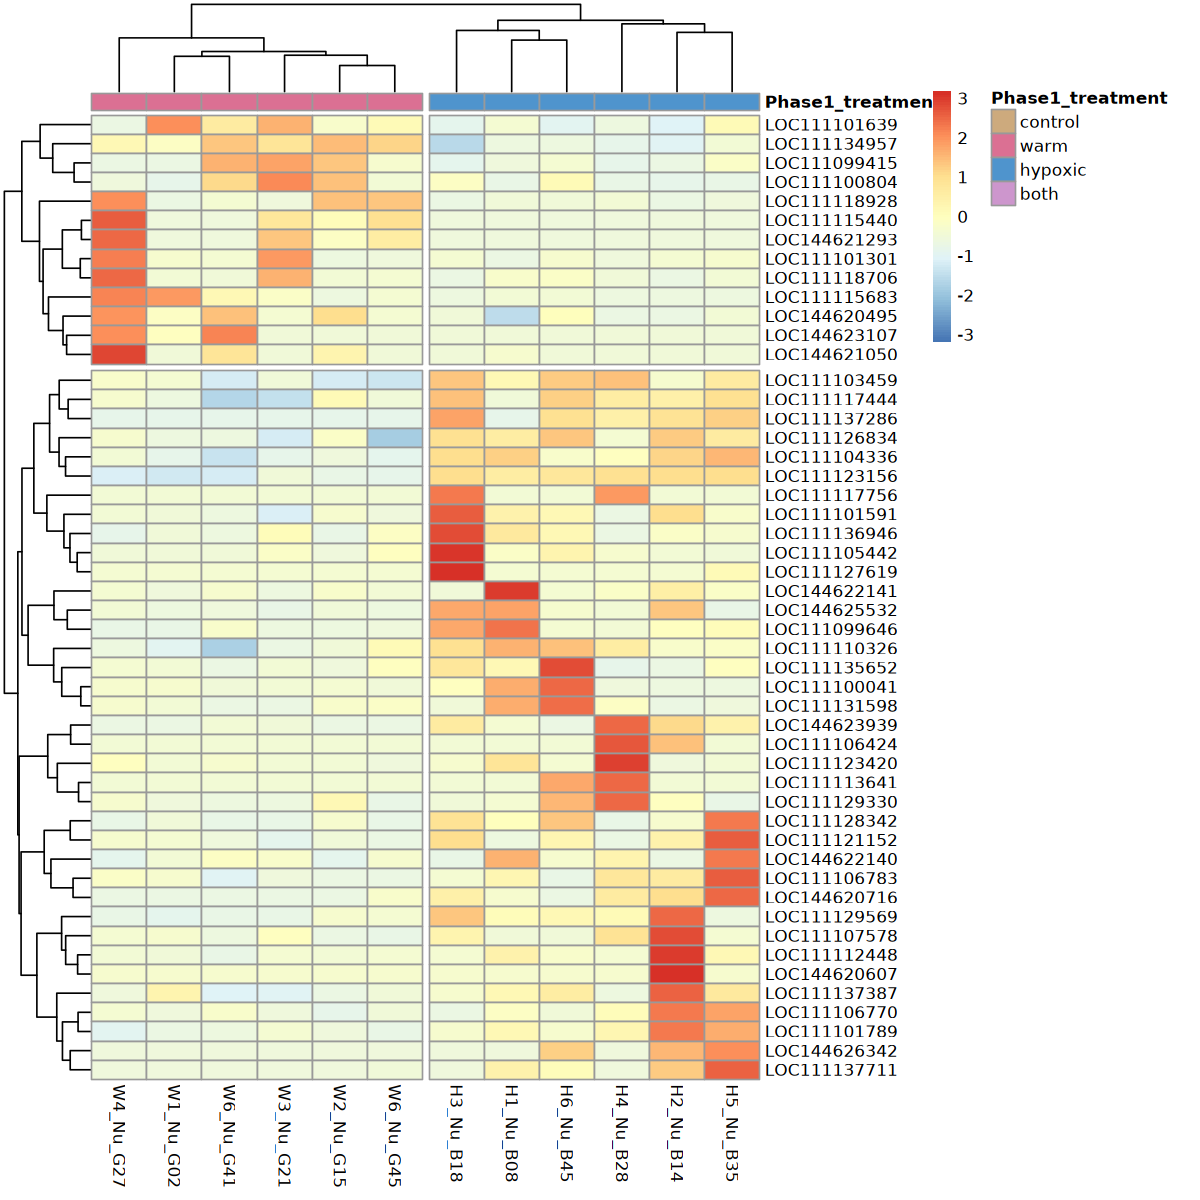

In [59]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(wh.matrix,
         # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 2,
        scale = 'row' # standardizes each gene separately across samples
        ) 

#### W vs. B

In [64]:
# pull sample names
wb_sample <- meta %>% filter(Phase1_treatment %in% c('warm', 'both')) %>% pull(Sample)

# pull rows and cols from vst matrix
wb.matrix <- vst[rownames(vst) %in% p1.deg$warm_v_both, colnames(vst) %in% wb_sample]

length(p1.deg$warm_v_both)
dim(wb.matrix)

[1] 83

[1] 83 11

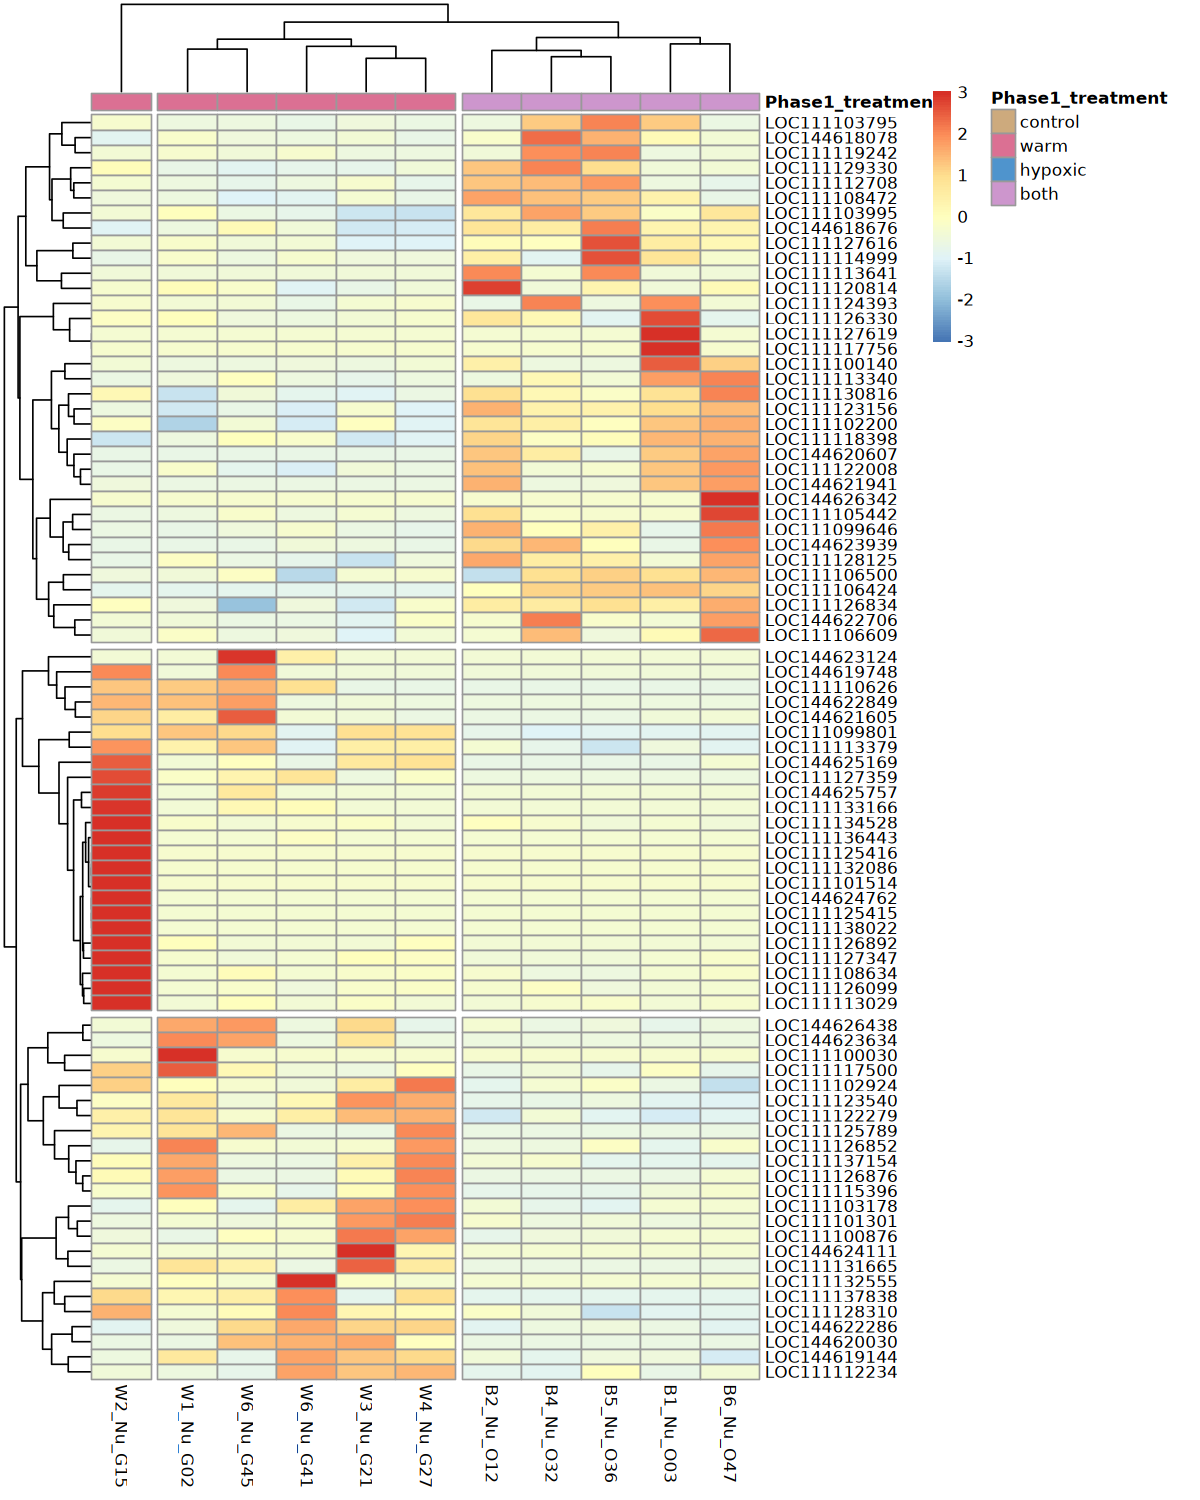

In [68]:
options(repr.plot.height = 12.5, repr.plot.width = 10)

pheatmap(wb.matrix,
         # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 3, 
         cutree_cols = 3,
        scale = 'row' # standardizes each gene separately across samples
        ) 

this makes W2_Nu_G15 look like a possible visual outlier, but when checking the other heatmaps, this sample doesn't stick out - so it's only when comparing it to Both samples

#### H vs. B

In [69]:
# pull sample names
hb_sample <- meta %>% filter(Phase1_treatment %in% c('hypoxic', 'both')) %>% pull(Sample)

# pull rows and cols from vst matrix
hb.matrix <- vst[rownames(vst) %in% p1.deg$hyp_v_both, colnames(vst) %in% hb_sample]

length(p1.deg$hyp_v_both)
dim(hb.matrix)

[1] 107

[1] 107  11

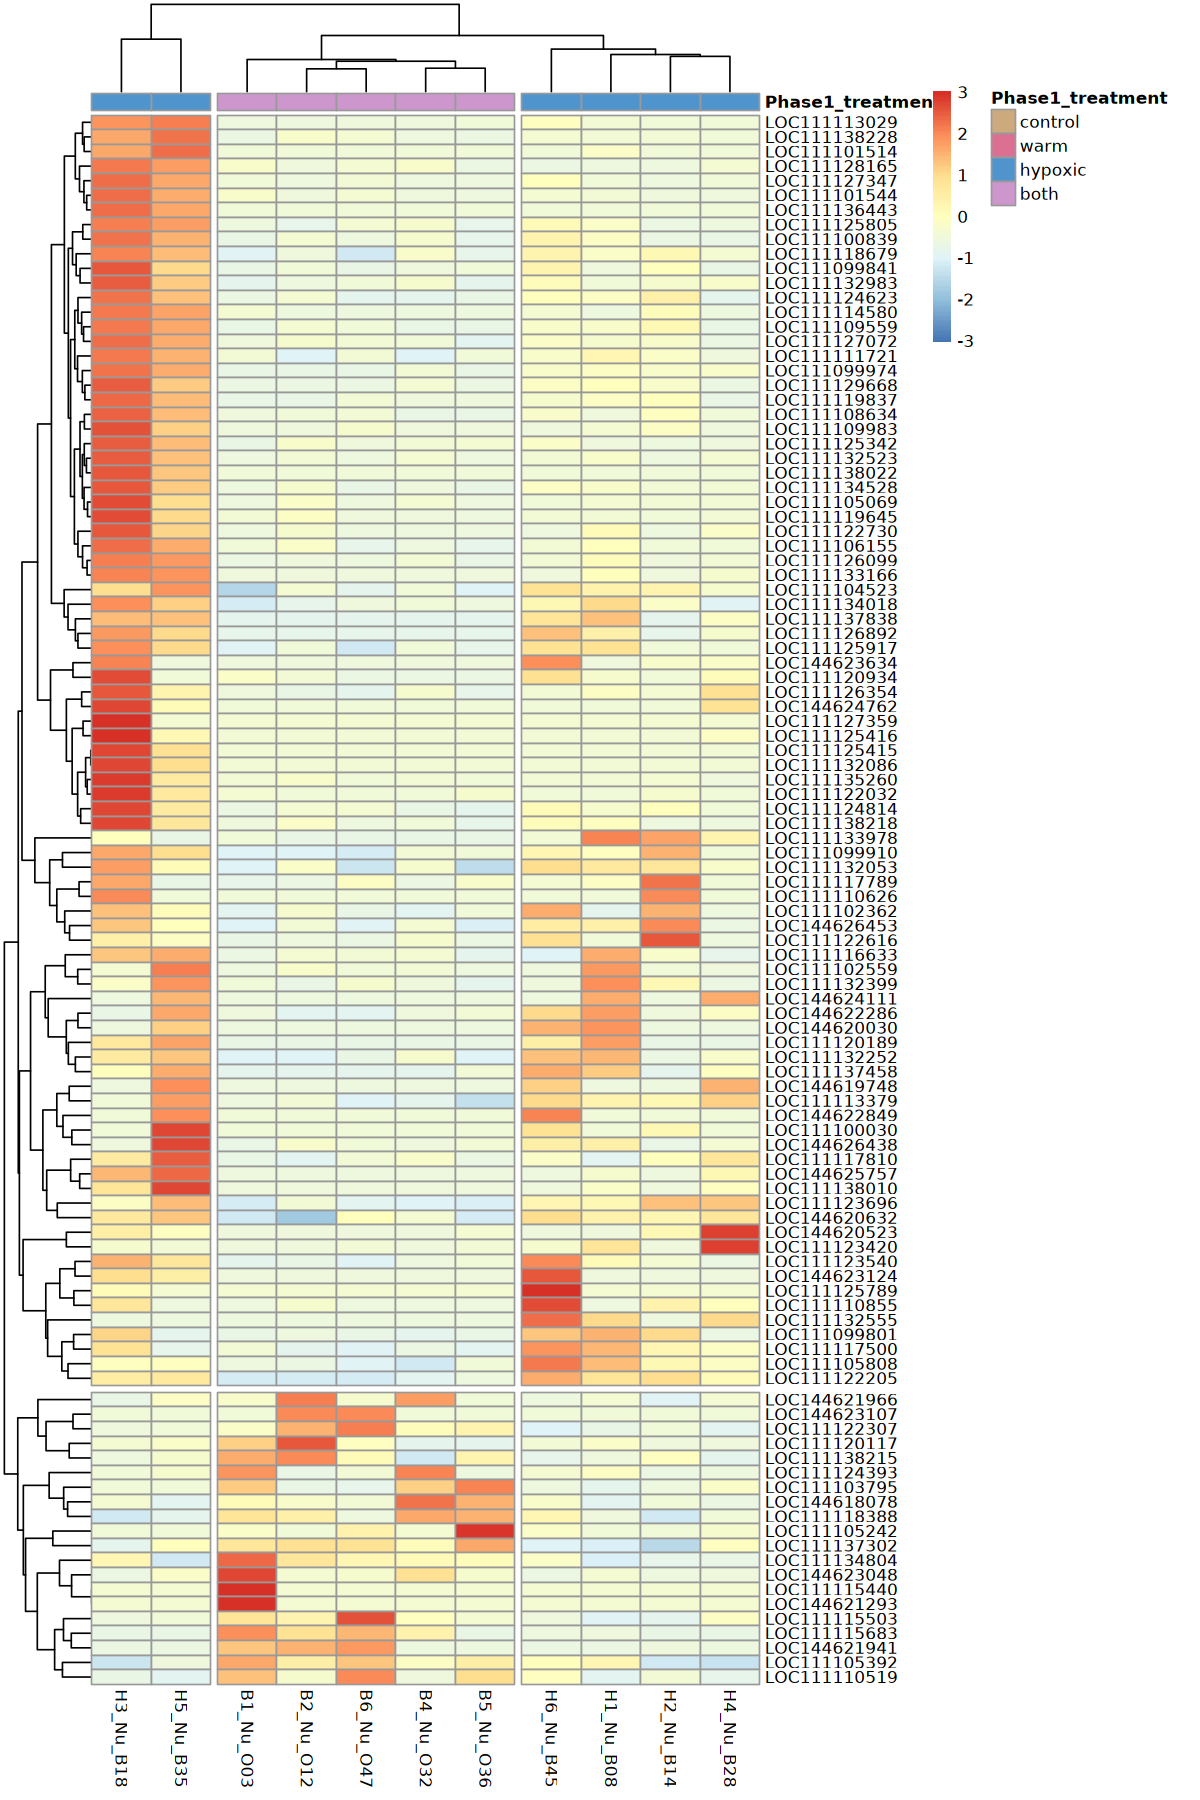

In [75]:
options(repr.plot.height = 15, repr.plot.width = 10)

pheatmap(hb.matrix,
          #cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 3,
        scale = 'row' # standardizes each gene separately across samples
        ) 